# Strong quasiperiodic KPM-SCF: M=40000 production and M=60000 audit

This notebook visualizes the full 256×256 charge density, the independent higher-degree audit, and the spatially localized production--audit differences. It reads the `density.csv`, `observables.toml`, and `final_audit.toml` written by the GPU run.

In [1]:
using CairoMakie
using FFTW
using LinearAlgebra
using Statistics
using TOML

In [2]:
# Change this one path after downloading the cluster result.
result_directory = joinpath(
    homedir(), "MPO_HF_analysis", "results",
    "separable_aubry_andre_lside8_strong_m40000_scf", "job_44048022",
)

density_file = joinpath(result_directory, "density.csv")
observables_file = joinpath(result_directory, "observables.toml")
audit_file = joinpath(result_directory, "final_audit.toml")
@assert isfile(density_file) "density.csv not found at $density_file"
@assert isfile(observables_file) "observables.toml not found at $observables_file"
@assert isfile(audit_file) "final_audit.toml not found at $audit_file"

In [3]:
parse_csv_fields(line) = split(replace(chomp(line), '"' => ""), ',')

function read_density_maps(path)
    open(path) do io
        header = parse_csv_fields(readline(io))
        column(name) = only(findall(==(name), header))
        xcol, ycol = column("x"), column("y")
        production_col, audit_col = column("production"), column("audit")
        rows = [parse_csv_fields(line) for line in eachline(io)]
        nx = maximum(parse(Int, row[xcol]) for row in rows) + 1
        ny = maximum(parse(Int, row[ycol]) for row in rows) + 1
        production = fill(NaN, nx, ny)
        audit = fill(NaN, nx, ny)
        for row in rows
            x, y = parse(Int, row[xcol]) + 1, parse(Int, row[ycol]) + 1
            production[x, y] = parse(Float64, row[production_col])
            audit[x, y] = parse(Float64, row[audit_col])
        end
        return production, audit
    end
end

production, audit = read_density_maps(density_file)
difference = audit - production
observables = TOML.parsefile(observables_file)
audit_summary = TOML.parsefile(audit_file)
worst = argmax(abs.(difference))
(; size=size(production),
   production_order=observables["checkerboard_order"],
   audit_order=audit_summary["audited_checkerboard_order"],
   difference_rms=norm(difference) / sqrt(length(difference)),
   difference_maximum=abs(difference[worst]),
   worst_site=(x=worst[1] - 1, y=worst[2] - 1,
               production=production[worst], audit=audit[worst]))

(size = (256, 256), production_order = -0.09612037074913536, audit_order = -0.09612032334913735, difference_rms = 1.8570319989356982e-5, difference_maximum = 0.004486809075023024, worst_site = (x = 241, y = 210, production = 0.4827984726355615, audit = 0.4783116635605385))

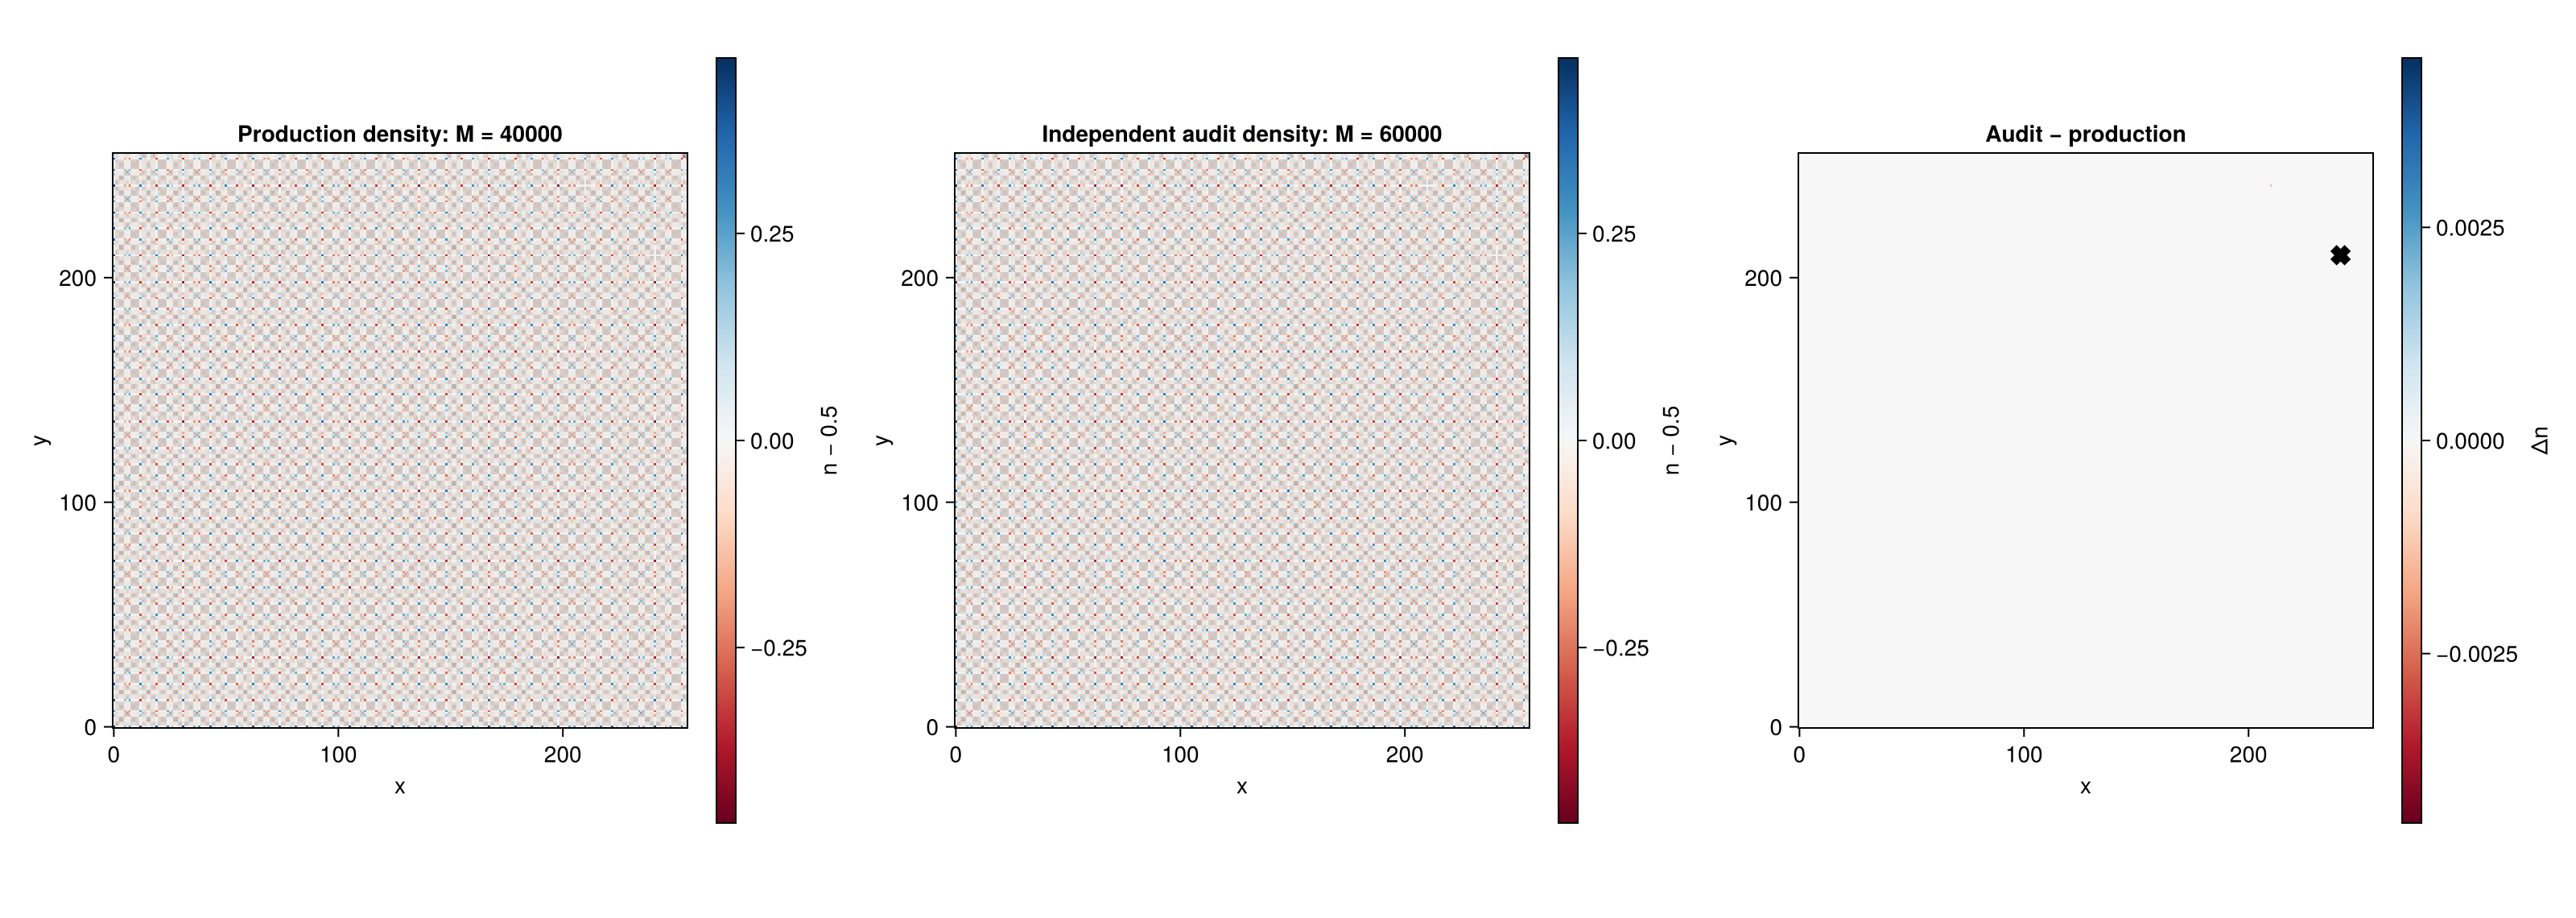

In [ ]:
# Density is displayed relative to half filling: white = n = 0.5.
density_scale = maximum(abs, vec(production .- 0.5))
x, y = 0:(size(production, 1) - 1), 0:(size(production, 2) - 1)

fig = Figure(size=(700, 570))
ax_production = Axis(fig[1, 1], title="Production density: M = 40000", xlabel="x", ylabel="y", aspect=DataAspect())

hm_production = heatmap!(ax_production, x, y, production .- 0.5; colormap=:RdBu, colorrange=(-density_scale, density_scale))
Colorbar(fig[1, 2], hm_production; label="n − 0.5")
fig


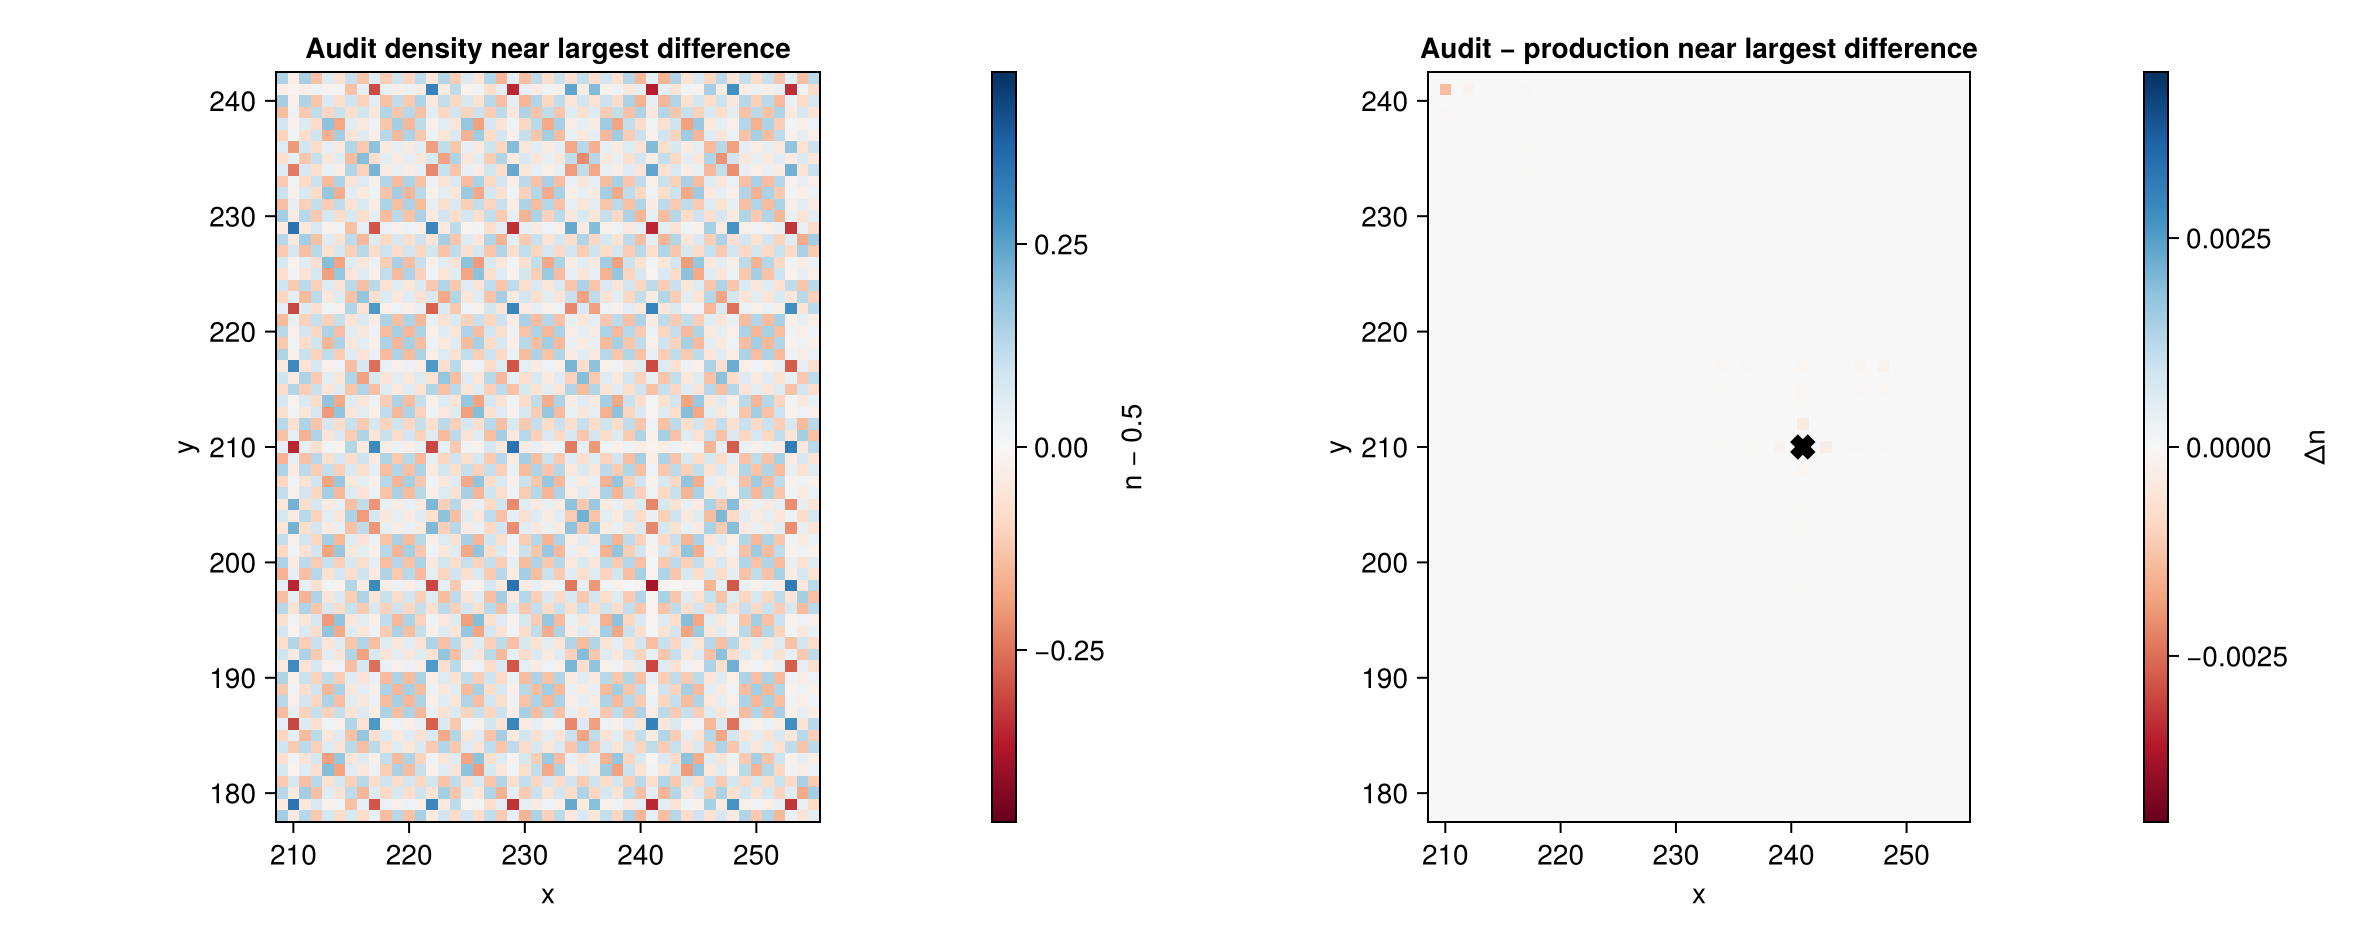

In [5]:
# Zoom around the site with the largest M=40000-to-M=60000 change.
halfwidth = 32
xrange = max(1, worst[1] - halfwidth):min(size(production, 1), worst[1] + halfwidth)
yrange = max(1, worst[2] - halfwidth):min(size(production, 2), worst[2] + halfwidth)

zoom = Figure(size=(1180, 470))
ax_density = Axis(zoom[1, 1], title="Audit density near largest difference", xlabel="x", ylabel="y", aspect=DataAspect())
ax_error = Axis(zoom[1, 3], title="Audit − production near largest difference", xlabel="x", ylabel="y", aspect=DataAspect())
hm_density = heatmap!(ax_density, x[xrange], y[yrange], audit[xrange, yrange] .- 0.5; colormap=:RdBu, colorrange=(-density_scale, density_scale))
hm_error = heatmap!(ax_error, x[xrange], y[yrange], difference[xrange, yrange]; colormap=:RdBu, colorrange=(-difference_scale, difference_scale))
scatter!(ax_error, [worst_x], [worst_y]; marker=:x, color=:black, markersize=14, strokewidth=2)
Colorbar(zoom[1, 2], hm_density; label="n − 0.5")
Colorbar(zoom[1, 4], hm_error; label="Δn")
zoom

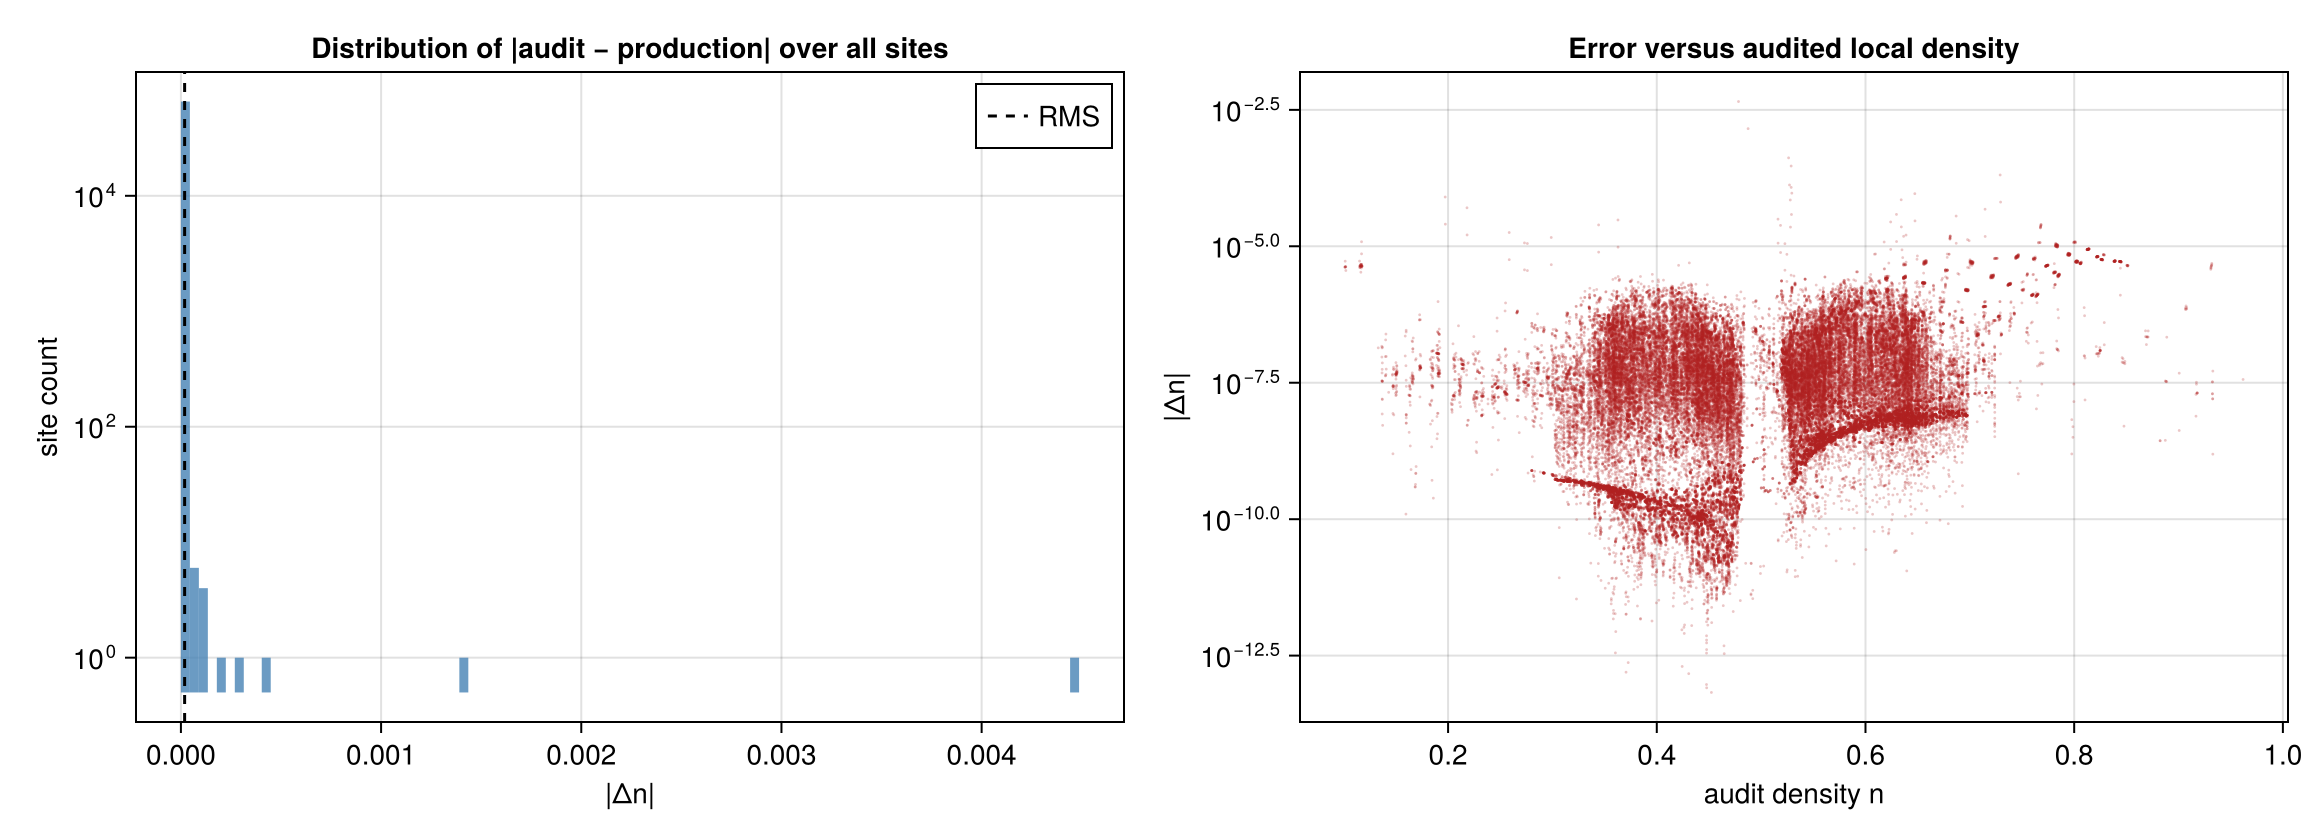

In [6]:
# Most sites should lie near zero; the tail identifies localized spikes.
absolute_difference = vec(abs.(difference))
quantile(absolute_difference, [0.5, 0.9, 0.99, 0.999, 1.0])

histfig = Figure(size=(1160, 420))
ax_hist = Axis(histfig[1, 1], title="Distribution of |audit − production| over all sites", xlabel="|Δn|", ylabel="site count", yscale=log10)
hist!(ax_hist, absolute_difference; bins=100, color=(:steelblue, 0.8))
vlines!(ax_hist, [sqrt(mean(abs2, difference))]; color=:black, linestyle=:dash, label="RMS")
axislegend(ax_hist)

ax_scatter = Axis(histfig[1, 2], title="Error versus audited local density", xlabel="audit density n", ylabel="|Δn|", yscale=log10)
scatter!(ax_scatter, vec(audit), max.(absolute_difference, eps()); markersize=2, color=(:firebrick, 0.25))
histfig

## Windowed Fourier spectrum

Open boundaries create a strong edge background. The Tukey window below suppresses it before the FFT. The cyan crosses mark the separable quasiperiodic sidebands around the checkerboard wavevector: (pi + 2 pi tau m, pi) and (pi, pi + 2 pi tau m), with m from -5 to 5.

In [ ]:
function tukey_window(n; alpha=0.25)
    0 <= alpha <= 1 || error("alpha must lie in [0, 1]")
    n > 1 || return ones(n)
    alpha == 0 && return ones(n)
    alpha == 1 && return 0.5 .* (1 .- cos.(2pi .* (0:n-1) ./ (n - 1)))
    u = (0:n-1) ./ (n - 1)
    [v < alpha / 2 ? 0.5 * (1 + cos(2pi * (v / alpha - 0.5))) :
     v <= 1 - alpha / 2 ? 1.0 :
     0.5 * (1 + cos(2pi * (v / alpha - 1 / alpha + 0.5))) for v in u]
end

window_alpha = 0.25
wx = tukey_window(size(audit, 1); alpha=window_alpha)
wy = tukey_window(size(audit, 2); alpha=window_alpha)
window = wx * wy'
density_fluctuation = audit .- mean(audit)
structure_factor = abs2.(fft(window .* density_fluctuation) ./ (length(audit) * mean(window)))
kx = 2pi .* (0:size(audit, 1)-1) ./ size(audit, 1)
ky = 2pi .* (0:size(audit, 2)-1) ./ size(audit, 2)
tau = sqrt(2.0) - 5.0 / 6.0
sidebands = [mod2pi(pi + 2pi * tau * m) for m in -5:5]

fftfig = Figure(size=(850, 720))
ax_fft = Axis(fftfig[1, 1], title="Tukey-windowed 2D density spectrum", xlabel="kx", ylabel="ky", xticks=([0, pi, 2pi], ["0", "pi", "2pi"]), yticks=([0, pi, 2pi], ["0", "pi", "2pi"]), aspect=DataAspect())
hm = heatmap!(ax_fft, kx, ky, log10.(structure_factor .+ eps()); colormap=:magma)
scatter!(ax_fft, sidebands, fill(pi, length(sidebands)); marker=:x, markersize=13, strokewidth=2, color=:cyan)
scatter!(ax_fft, fill(pi, length(sidebands)), sidebands; marker=:x, markersize=13, strokewidth=2, color=:cyan)
Colorbar(fftfig[1, 2], hm, label="log10 windowed spectral weight")
fftfig

## Export figures for the KPM methods note

Run this cell after the plot cells. It writes PDF figures to the repository documentation directory used by `docs/kpm_hadamard_methods.tex`.

In [ ]:
figure_directory = normpath(joinpath(@__DIR__, "..", "docs", "figures", "strong_m40000"))
mkpath(figure_directory)
save(joinpath(figure_directory, "density_full.pdf"), fig)
save(joinpath(figure_directory, "density_audit_difference.pdf"), zoom)
save(joinpath(figure_directory, "density_error_distribution.pdf"), histfig)
save(joinpath(figure_directory, "density_fft_tukey.pdf"), fftfig)
readdir(figure_directory)